# `Auth.md`를 이용한 사용자 권한별 skills.md 접근

>  auth.md → 선택적 skills.md 접근 → Tool Layer 실험

In [39]:
import re
import yaml
import numpy as np
from dotenv import load_dotenv
from collections import defaultdict
from dataclasses import dataclass, field
from deepagents import create_deep_agent
from langchain_core.tools import StructuredTool

load_dotenv()

MODEL = "anthropic:claude-haiku-4-5-20251001"
print(f"모델: {MODEL}")
print("실험준비 완료")

모델: anthropic:claude-haiku-4-5-20251001
실험준비 완료


## 아키텍처

```
사용자
  ↓
auth.md  (skill:* 스코프만 정의)
  ↓
get_accessible_skills()  → skill:* 스코프로 필터링
  ↓
skill_tool 실행  → skill 권한 = tool 실행 권한 (별도 체크 없음)
  ↓
Tool Layer  (원자적 실행)
```

### 핵심 원칙
- `auth.md`의 `skill:*` 스코프 하나가 **스킬 접근 + 내부 tool 실행**을 모두 보장
- `skill:reporting` 보유 → `reporting_skill` 접근 가능 + 내부 tool 전부 실행 가능
- 별도 `read:*/write:*` 스코프 불필요 — skill 권한이 tool 권한을 내포

---

## Part 1: auth.md — skill:* 스코프 단일 소스

`skill:*` 스코프만 정의한다. `read:*/write:*` tool 스코프는 roles에 없다.

- `scopes` = skill 권한 토큰 카탈로그
- `roles` = 역할별 보유 skill 스코프 선언
- skill 스코프 보유 → 해당 스킬의 모든 내부 tool 실행 권한 포함

In [40]:
def parse_auth_md(content: str) -> dict:
    match = re.match(r"^---\n(.*?)\n---", content, re.DOTALL)
    if not match:
        raise ValueError("auth.md에 YAML frontmatter가 없습니다.")
    return yaml.safe_load(match.group(1))


AUTH_MD_CONTENT = """
---
version: "1.0"
service: "research-platform.internal"

scopes:
  skill:research:      "research_skill 실행 권한 (내부 tool 포함)"
  skill:data_analysis: "data_analysis_skill 실행 권한 (내부 tool 포함)"
  skill:notification:  "notification_skill 실행 권한 (내부 tool 포함)"
  skill:reporting:     "reporting_skill 실행 권한 (내부 tool 포함)"
  skill:code_review:   "code_review_skill 실행 권한 (내부 tool 포함)"

roles:
  admin:
    - skill:research
    - skill:data_analysis
    - skill:notification
    - skill:reporting
    - skill:code_review

  analyst:
    - skill:research
    - skill:data_analysis
    - skill:reporting

  analyst_restricted:
    - skill:research
    - skill:data_analysis
    # skill:reporting / skill:notification / skill:code_review 없음

  developer:
    - skill:research
    - skill:notification
    - skill:code_review

  viewer:
    - skill:research

  guest: []
---
"""

AUTH_MD = parse_auth_md(AUTH_MD_CONTENT.strip())

print("서비스:", AUTH_MD["service"])
print("\n스코프 (skill:* 전용):")
for s, d in AUTH_MD["scopes"].items():
    print(f"  {s:22s} | {d}")
print("\n역할별 skill 스코프:")
for role, scopes in AUTH_MD["roles"].items():
    print(f"  {role:20s} | {sorted(scopes)}")

서비스: research-platform.internal

스코프 (skill:* 전용):
  skill:research         | research_skill 실행 권한 (내부 tool 포함)
  skill:data_analysis    | data_analysis_skill 실행 권한 (내부 tool 포함)
  skill:notification     | notification_skill 실행 권한 (내부 tool 포함)
  skill:reporting        | reporting_skill 실행 권한 (내부 tool 포함)
  skill:code_review      | code_review_skill 실행 권한 (내부 tool 포함)

역할별 skill 스코프:
  admin                | ['skill:code_review', 'skill:data_analysis', 'skill:notification', 'skill:reporting', 'skill:research']
  analyst              | ['skill:data_analysis', 'skill:reporting', 'skill:research']
  analyst_restricted   | ['skill:data_analysis', 'skill:research']
  developer            | ['skill:code_review', 'skill:notification', 'skill:research']
  viewer               | ['skill:research']
  guest                | []


In [41]:
class AuthContext:
    """
    auth.md 기반 권한 컨텍스트.
    skill:* 스코프만 관리한다. skill 권한 = 내부 tool 실행 권한 포함.
    """
    def __init__(self, user_id: str, role: str, auth_md: dict | None = None):
        self.user_id = user_id
        self.role = role
        _md = auth_md or AUTH_MD
        self.scopes: set[str] = set(_md["roles"].get(role, []))

    def can_access_skill(self, skill_scope: str) -> bool:
        """skill:* 스코프 보유 여부 — 이 권한 하나로 스킬 + 내부 tool 모두 허용."""
        return skill_scope in self.scopes

    def upgrade_scope(self, new_scope: str, reason: str = "OTP claim confirmed"):
        if new_scope in AUTH_MD["scopes"]:
            self.scopes.add(new_scope)
            print(f"[AuthContext] scope 업그레이드: '{new_scope}' ({reason})")
            print(f"[AuthContext] 현재 scopes: {sorted(self.scopes)}")
        else:
            print(f"[AuthContext] 알 수 없는 scope: '{new_scope}'")

    def __repr__(self):
        return f"AuthContext(user={self.user_id}, role={self.role})"


users = {
    "alice":   AuthContext("alice",   "admin"),
    "diana":   AuthContext("diana",   "analyst"),
    "diana_r": AuthContext("diana_r", "analyst_restricted"),
    "bob":     AuthContext("bob",     "developer"),
    "carol":   AuthContext("carol",   "viewer"),
    "guest1":  AuthContext("guest1",  "guest"),
}

print(f"{'사용자':12s} | {'역할':20s} | skill 스코프")
print("-" * 75)
for name, ctx in users.items():
    print(f"  {name:10s} | {ctx.role:20s} | {sorted(ctx.scopes)}")

사용자          | 역할                   | skill 스코프
---------------------------------------------------------------------------
  alice      | admin                | ['skill:code_review', 'skill:data_analysis', 'skill:notification', 'skill:reporting', 'skill:research']
  diana      | analyst              | ['skill:data_analysis', 'skill:reporting', 'skill:research']
  diana_r    | analyst_restricted   | ['skill:data_analysis', 'skill:research']
  bob        | developer            | ['skill:code_review', 'skill:notification', 'skill:research']
  carol      | viewer               | ['skill:research']
  guest1     | guest                | []


## Part 2: SKILL_REGISTRY — skill:* 스코프와 StructuredTool의 직접 매핑

`SKILLS_MD` 없음. 스킬은 `scope → StructuredTool`로 직접 정의한다.  
내부 구현(tool 호출 여부, 횟수)은 auth 관점에서 무관하다.

In [ ]:
import secrets, json

def _research(request: str) -> str:
    return json.dumps({
        "session_id": secrets.token_hex(4),
        "sources": [
            {"url": "docs.langchain.com/v1/changelog",  "relevance": 0.94},
            {"url": "github.com/langchain-ai/langchain", "relevance": 0.91},
        ],
        "summary": f"'{request}' 관련 외부 문서 5건 수집 완료",
    }, ensure_ascii=False)

def _data_analysis(request: str) -> str:
    return json.dumps({
        "trace_id":     secrets.token_hex(4),
        "rows_fetched": 1243,
        "stats":        {"mean": 125_000, "std": 18_000, "trend": "+12%"},
        "source":       "internal_db://sales_2024",
        "summary":      f"'{request}' DB 조회 및 통계 처리 완료",
    }, ensure_ascii=False)

def _notification(request: str) -> str:
    return json.dumps({
        "message_id": secrets.token_hex(4),
        "channel":    "#dev-team",
        "status":     "delivered",
        "recipients": 8,
    }, ensure_ascii=False)

def _reporting(request: str) -> str:
    return json.dumps({
        "report_id":      secrets.token_hex(4),
        "sections":       ["executive_summary", "data_analysis", "recommendations"],
        "pages":          12,
        "distributed_to": ["team@company.com"],
    }, ensure_ascii=False)

def _code_review(request: str) -> str:
    return json.dumps({
        "review_id": secrets.token_hex(4),
        "target":    request,
        "issues":    [{"line": 42, "severity": "warning", "msg": "Unused variable detected"}],
        "score":     87,
    }, ensure_ascii=False)


SKILL_REGISTRY: dict[str, StructuredTool] = {
    "skill:research": StructuredTool.from_function(
        _research, name="research_skill",
        description="외부 웹 크롤러를 호출해 실시간 정보를 수집한다. 실행 session_id와 source URL이 포함된 결과를 반환한다.",
    ),
    "skill:data_analysis": StructuredTool.from_function(
        _data_analysis, name="data_analysis_skill",
        description="내부 DB에서 데이터를 조회하고 통계를 계산한다. trace_id와 rows_fetched가 포함된 결과를 반환한다.",
    ),
    "skill:notification": StructuredTool.from_function(
        _notification, name="notification_skill",
        description="Slack 채널에 알림을 발송한다. 발송 완료 후 message_id와 수신자 수를 반환한다.",
    ),
    # ↓ 수정: 외부 시스템 의존성 명시 → LLM 자체 답변(hallucination) 방지
    "skill:reporting": StructuredTool.from_function(
        _reporting, name="reporting_skill",
        description="외부 보고서 배포 시스템을 호출해 리포트를 생성·배포한다. LLM이 자체 생성할 수 없는 실행 고유 report_id와 실제 배포 이메일 목록을 반환한다.",
    ),
    "skill:code_review": StructuredTool.from_function(
        _code_review, name="code_review_skill",
        description="외부 정적 분석 엔진을 호출해 소스 코드 이슈를 탐지한다. LLM이 자체 생성할 수 없는 실행 고유 review_id와 실제 탐지된 이슈 목록을 반환한다.",
    ),
}

print("SKILL_REGISTRY (scope → StructuredTool):")
for scope, tool in SKILL_REGISTRY.items():
    print(f"  {scope:25s} → {tool.name}")
    print(f"    description: {tool.description[:70]}...")


---
## Part 3: Agent 구현

In [43]:
def create_agent(auth_ctx: AuthContext, verbose: bool = True):
    """
    시나리오:
    ① 사용자 → agent 접근 + 지시문
    ② auth.md 참조 → AuthContext로 사용자 권한 확인
    ③ SKILL_REGISTRY에서 can_access_skill()로 접근 가능 스킬 필터링
    ④ 접근 가능 스킬만 로드한 agent 반환
    """
    accessible = {
        scope: tool
        for scope, tool in SKILL_REGISTRY.items()
        if auth_ctx.can_access_skill(scope)
    }
    blocked = [SKILL_REGISTRY[s].name for s in SKILL_REGISTRY if s not in accessible]

    if verbose:
        print(f"\n{'='*60}")
        print(f"[Agent] {auth_ctx.user_id:15s} | role: {auth_ctx.role}")
        print(f"[Scopes] {sorted(auth_ctx.scopes)}")
        print(f"[접근 가능] ({len(accessible)}개): {[t.name for t in accessible.values()]}")
        print(f"[차단]     ({len(blocked)}개): {blocked}")
        print(f"{'='*60}")

    if not accessible:
        if verbose:
            print("[Agent] 접근 가능한 skill 없음 → agent 생성 불가")
        return None

    return create_deep_agent(model=MODEL, tools=list(accessible.values()))


def run_test(auth_ctx: AuthContext, query: str, agent=None):
    if agent is None:
        agent = create_agent(auth_ctx)
    if agent is None:
        print(f"[결과] {auth_ctx.user_id}: 실행 불가\n")
        return None
    print(f"\n[쿼리] {query}")
    result = agent.invoke({"messages": [{"role": "user", "content": query}]})
    final = result["messages"][-1].content
    print(f"[응답] {final[:400]}{'...' if len(final) > 400 else ''}\n")
    return agent

---
## Experiment 1: 역할별 skill 스코프 기반 접근 제어

EXPERIMENT 1: 역할별 접근 제어

[Agent] alice           | role: admin
[Scopes] ['skill:code_review', 'skill:data_analysis', 'skill:notification', 'skill:reporting', 'skill:research']
[접근 가능] (5개): ['research_skill', 'data_analysis_skill', 'notification_skill', 'reporting_skill', 'code_review_skill']
[차단]     (0개): []

[쿼리] 이번 달 성과 리포트를 생성하고 팀에게 배포해줘.
[응답] 이번 달 성과 리포트를 생성하고 배포하기 위해 몇 가지 정보가 필요합니다:

1. **데이터 소스**: 성과 데이터가 어디에 있나요? (DB, 스프레드시트, 파일 경로 등)
2. **리포트 범위**: 어느 팀의 성과를 포함해야 하나요?
3. **핵심 메트릭**: 어떤 지표들을 중심으로 리포트를 작성해야 하나요? (매출, KPI, 프로젝트 완료율 등)
4. **배포 대상**: 누구에게 보내야 하나요? (팀 이메일, 특정 인원 등)
5. **리포트 형식**: 선호하는 형식이 있나요? (PDF, 이메일, 스프레드시트 등)

이 정보들을 알려주시면 바로 리포트를 생성하고 배포하겠습니다.



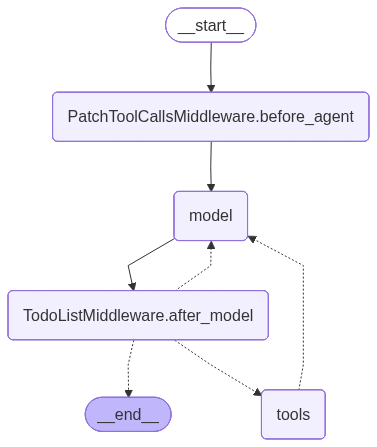

In [44]:
Q_ANALYSIS = "sales 데이터를 분석하고 결과를 정리해줘."
Q_REPORT   = "이번 달 성과 리포트를 생성하고 팀에게 배포해줘."
Q_RESEARCH = "LangChain v1.0 변경사항을 리서치해줘."
Q_NOTIFY   = "개발팀에 배포 완료 알림을 Slack으로 보내줘."

print("=" * 60)
print("EXPERIMENT 1: 역할별 접근 제어")
print("=" * 60)

# admin: 모든 skill 스코프 보유
run_test(users["alice"], Q_REPORT)

---


[Agent] diana           | role: analyst
[Scopes] ['skill:data_analysis', 'skill:reporting', 'skill:research']
[접근 가능] (3개): ['research_skill', 'data_analysis_skill', 'reporting_skill']
[차단]     (2개): ['notification_skill', 'code_review_skill']

[쿼리] sales 데이터를 분석하고 결과를 정리해줘.
[응답] sales 데이터를 찾을 수 없습니다. 다음을 확인해주세요:

1. **파일 위치**: sales 데이터가 어디에 있는지 (절대 경로)
2. **파일 형식**: CSV, Excel, JSON 등 어떤 형식인지
3. **현재 작업 디렉토리**: 데이터가 저장된 디렉토리

파일의 위치를 알려주시면 분석을 진행하겠습니다.



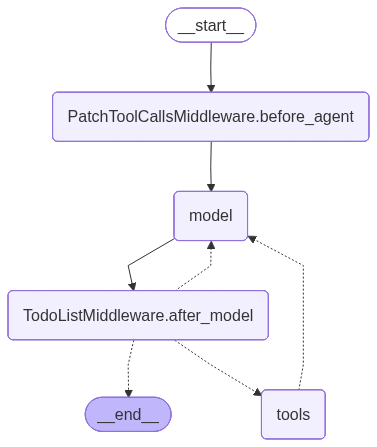

In [45]:
# analyst: skill:data_analysis 보유 → data_analysis_skill 실행
run_test(users["diana"], Q_ANALYSIS)


[케이스] analyst_restricted — skill:reporting 없음

[Agent] diana_r         | role: analyst_restricted
[Scopes] ['skill:data_analysis', 'skill:research']
[접근 가능] (2개): ['research_skill', 'data_analysis_skill']
[차단]     (3개): ['notification_skill', 'reporting_skill', 'code_review_skill']

[쿼리] 이번 달 성과 리포트를 생성하고 팀에게 배포해줘.
[응답] 작업 환경에 기존 파일이 없는 것 같습니다. 위의 질문들에 답변해주시면 성과 리포트를 생성하고 배포하겠습니다.



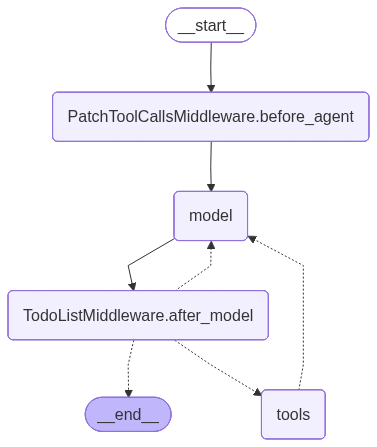

In [46]:
# analyst_restricted: skill:reporting 없음 → reporting_skill 차단
print("\n[케이스] analyst_restricted — skill:reporting 없음")
run_test(users["diana_r"], Q_REPORT)


[Agent] carol           | role: viewer
[Scopes] ['skill:research']
[접근 가능] (1개): ['research_skill']
[차단]     (4개): ['data_analysis_skill', 'notification_skill', 'reporting_skill', 'code_review_skill']

[쿼리] LangChain v1.0 변경사항을 리서치해줘.
[응답] 리서치 결과를 정리해서 제시하겠습니다:

## LangChain v1.0 주요 변경사항

### 1. **Core 라이브러리 분리**
   - `langchain-core` 별도 패키지로 분리
   - 더 가벼운 의존성과 빠른 업데이트 가능
   - 기본 인터페이스와 기반 클래스 포함

### 2. **LangSmith 통합 강화**
   - 추적(Tracing) 및 디버깅 기능 기본 포함
   - LangSmith와의 더 긴밀한 통합

### 3. **Runnable 인터페이스 표준화**
   - 모든 구성 요소가 `Runnable` 인터페이스 준수
   - 더 일관된 API와 체인 구성
   - `pipe()` 연산자를 통한 직관적인 체인 구성

### 4. **Message 시스템 개선**
   - L...



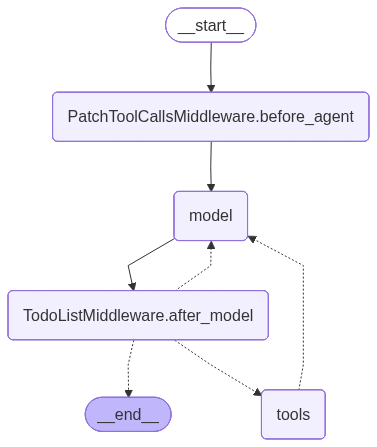

In [47]:
# viewer: skill:research만 보유
run_test(users["carol"], Q_RESEARCH)

In [48]:
# guest: 스코프 없음 → 모든 스킬 차단
run_test(users["guest1"], Q_RESEARCH)


[Agent] guest1          | role: guest
[Scopes] []
[접근 가능] (0개): []
[차단]     (5개): ['research_skill', 'data_analysis_skill', 'notification_skill', 'reporting_skill', 'code_review_skill']
[Agent] 접근 가능한 skill 없음 → agent 생성 불가
[결과] guest1: 실행 불가




EXPERIMENT 2: skill 스코프 업그레이드 (OTP 플로우)

[Step 1] skill:reporting 없음 → reporting_skill 차단

[Agent] diana_r2        | role: analyst_restricted
[Scopes] ['skill:data_analysis', 'skill:research']
[접근 가능] (2개): ['research_skill', 'data_analysis_skill']
[차단]     (3개): ['notification_skill', 'reporting_skill', 'code_review_skill']

[쿼리] 이번 달 성과 리포트를 생성하고 팀에게 배포해줘.
[응답] 현재 작업 환경에 데이터가 없는 것으로 보입니다. 위의 4가지 정보를 제공해주면 리포트를 생성하고 배포하도록 하겠습니다.

[OTP 플로우]
  POST /agent/auth/claim          -> OTP 이메일 발송
  POST /agent/auth/claim/complete -> 검증 완료
[AuthContext] scope 업그레이드: 'skill:reporting' (OTP claim confirmed)
[AuthContext] 현재 scopes: ['skill:data_analysis', 'skill:reporting', 'skill:research']

[Step 2] skill:reporting 획득 → reporting_skill 노출 + 실행

[Agent] diana_r2        | role: analyst_restricted
[Scopes] ['skill:data_analysis', 'skill:reporting', 'skill:research']
[접근 가능] (3개): ['research_skill', 'data_analysis_skill', 'reporting_skill']
[차단]     (2개): ['notification_skill', 'code_review_skill']

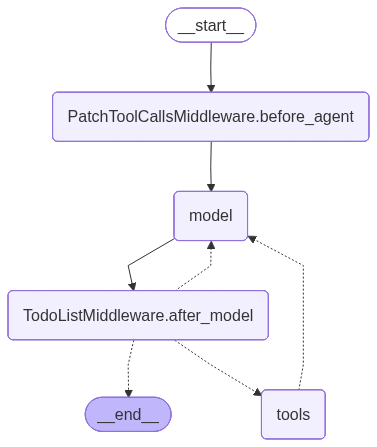

In [49]:
print("\n" + "=" * 60)
print("EXPERIMENT 2: skill 스코프 업그레이드 (OTP 플로우)")
print("=" * 60)

diana_r2 = AuthContext("diana_r2", "analyst_restricted")

print("\n[Step 1] skill:reporting 없음 → reporting_skill 차단")
agent = run_test(diana_r2, Q_REPORT)

print("[OTP 플로우]")
print("  POST /agent/auth/claim          -> OTP 이메일 발송")
print("  POST /agent/auth/claim/complete -> 검증 완료")
diana_r2.upgrade_scope("skill:reporting", reason="OTP claim confirmed")

print("\n[Step 2] skill:reporting 획득 → reporting_skill 노출 + 실행")
run_test(diana_r2, Q_REPORT)

---
## Part 4: Pass Rate 측정 — 25개 시나리오 (6역할 × 5skill)

각 역할이 각 skill을 **명시적으로 호출하도록 지시**하는 25개 시나리오를 실제 agent 실행 환경에서 검증한다.

| 지표 | 정의 | 특성 |
|---|---|---|
| **Static** | auth.md 기반 접근 가능 skill 수 | 이론값, LLM 없음, 결정론적 |
| **Exec** | 허용된 skill 중 LLM이 실제 호출한 수 | 실행 환경 검증, LLM 실행 |
| **Total** | 25개 시나리오 정합률 | 허용→호출 + 차단→미호출 |

**시나리오 지시문 설계 원칙**  
쿼리에 tool 이름을 명시(`research_skill을 호출해서 ...`)하여 LLM routing 오류를 최소화.  
tool이 agent 목록에 있으면 호출 가능, 없으면 호출 불가 → 권한 시스템의 실행 충실도 측정.


In [125]:
TEST_MATRIX = [
    {
        "name": "리서치",
        "query": "research_skill을 실행해줘. request 파라미터로 'langchain'을 전달해.",
        "required_skill": "skill:research",
    },
    {
        "name": "데이터분석",
        "query": "data_analysis_skill을 실행해줘. request 파라미터로 'sales'를 전달해.",
        "required_skill": "skill:data_analysis",
    },
    {
        "name": "알림발송",
        "query": "notification_skill을 실행해줘. request 파라미터로 'deploy'를 전달해.",
        "required_skill": "skill:notification",
    },
    {
        "name": "통합리포트",
        "query": "reporting_skill을 실행해줘. request 파라미터로 'monthly'를 전달해.",
        "required_skill": "skill:reporting",
    },
    {
        "name": "코드리뷰",
        "query": "code_review_skill을 실행해줘. request 파라미터로 'main.py'를 전달해.",
        "required_skill": "skill:code_review",
    },
]

ROLES_TO_TEST = ["admin", "analyst", "analyst_restricted", "developer", "viewer", "guest"]
print(f"총 시나리오: {len(ROLES_TO_TEST)}개 역할 × {len(TEST_MATRIX)}개 skill = {len(ROLES_TO_TEST) * len(TEST_MATRIX)}개")
print()
for tc in TEST_MATRIX:
    print(f"  {tc['name']:10s} | {tc['required_skill']:25s} | {tc['query']}")


총 시나리오: 6개 역할 × 5개 skill = 30개

  리서치        | skill:research            | research_skill을 실행해줘. request 파라미터로 'langchain'을 전달해.
  데이터분석      | skill:data_analysis       | data_analysis_skill을 실행해줘. request 파라미터로 'sales'를 전달해.
  알림발송       | skill:notification        | notification_skill을 실행해줘. request 파라미터로 'deploy'를 전달해.
  통합리포트      | skill:reporting           | reporting_skill을 실행해줘. request 파라미터로 'monthly'를 전달해.
  코드리뷰       | skill:code_review         | code_review_skill을 실행해줘. request 파라미터로 'main.py'를 전달해.


---

In [126]:
import functools

@dataclass
class SkillAccessTracker:
    role: str
    query_results: list = field(default_factory=list)
    _current_called: set = field(default_factory=set)

    def begin_query(self):
        self._current_called.clear()

    def record_tool_call(self, scope: str):
        self._current_called.add(scope)

    def record_query(self, name: str, required_scope: str, auth_ok: bool):
        exec_ok = (required_scope in self._current_called) if auth_ok else False
        self.query_results.append({
            "name":      name,
            "auth_pass": auth_ok,
            "exec_pass": exec_ok,
        })

    @property
    def static_pass_rate(self) -> float:
        n = len(self.query_results)
        return sum(1 for r in self.query_results if r["auth_pass"]) / n if n > 0 else 0.0

    @property
    def exec_pass_rate(self) -> float:
        allowed = [r for r in self.query_results if r["auth_pass"]]
        return sum(1 for r in allowed if r["exec_pass"]) / len(allowed) if allowed else 0.0

    @property
    def total_pass_rate(self) -> float:
        n = len(self.query_results)
        correct = sum(
            1 for r in self.query_results
            if (r["auth_pass"] and r["exec_pass"]) or (not r["auth_pass"])
        )
        return correct / n if n > 0 else 0.0


def wrap_for_tracking(scope: str, tool: StructuredTool, tracker: SkillAccessTracker) -> StructuredTool:
    original = tool.func
    @functools.wraps(original)
    def tracked(*args, **kwargs):
        result = original(*args, **kwargs)
        tracker.record_tool_call(scope)
        return result
    # args_schema 명시 → functools.wraps 이후 schema 추론 오류 방지
    return StructuredTool.from_function(
        tracked,
        name=tool.name,
        description=tool.description,
        args_schema=tool.args_schema,
    )


print("SkillAccessTracker + wrap_for_tracking 준비 완료")
print("  static_pass_rate  → 역할에 허용된 skill 비율 (결정론적)")
print("  exec_pass_rate    → 허용된 skill 중 LLM이 실제 호출한 비율")
print("  total_pass_rate   → 전체 시나리오 정합률 (허용→호출 + 차단→미호출)")


SkillAccessTracker + wrap_for_tracking 준비 완료
  static_pass_rate  → 역할에 허용된 skill 비율 (결정론적)
  exec_pass_rate    → 허용된 skill 중 LLM이 실제 호출한 비율
  total_pass_rate   → 전체 시나리오 정합률 (허용→호출 + 차단→미호출)


In [127]:
print("=== 진단 1: wrap_for_tracking schema 보존 여부 ===\n")

ctx_diag = AuthContext("diag", "admin")
diag_tracker = SkillAccessTracker(role="diag")

for scope, orig_tool in SKILL_REGISTRY.items():
    wrapped = wrap_for_tracking(scope, orig_tool, diag_tracker)

    orig_props = set(orig_tool.args_schema.schema().get("properties", {}).keys()) if orig_tool.args_schema else set()
    wrap_props = set(wrapped.args_schema.schema().get("properties", {}).keys()) if wrapped.args_schema else set()
    match = "✓" if orig_props == wrap_props else "✗ 불일치!"

    print(f"  {scope}")
    print(f"    원본 args : {sorted(orig_props)}")
    print(f"    래핑 args : {sorted(wrap_props)}")
    print(f"    schema    : {match}")

print("\n=== 진단 2: 실패 시나리오 LLM 응답 확인 (admin 기준) ===\n")

accessible_admin = {s for s in SKILL_REGISTRY if ctx_diag.can_access_skill(s)}

fail_cases = [
    {"name": "통합리포트", "tc": TEST_MATRIX[3], "scope": "skill:reporting"},
    {"name": "코드리뷰",   "tc": TEST_MATRIX[4], "scope": "skill:code_review"},
]

for case in fail_cases:
    diag_t = SkillAccessTracker(role="admin_diag")
    tools  = [wrap_for_tracking(s, SKILL_REGISTRY[s], diag_t) for s in accessible_admin]
    agent  = create_deep_agent(model=MODEL, tools=tools)

    diag_t.begin_query()
    result     = agent.invoke({"messages": [{"role": "user", "content": case["tc"]["query"]}]})
    final_msg  = result["messages"][-1].content
    called     = case["scope"] in diag_t._current_called

    print(f"[{case['name']}]  tool 호출: {'✓' if called else '✗ 미호출'}")
    print(f"  쿼리  : {case['tc']['query']}")
    print(f"  응답  : {final_msg[:300]}{'...' if len(final_msg) > 300 else ''}")
    print()


=== 진단 1: wrap_for_tracking schema 보존 여부 ===

  skill:research
    원본 args : ['request']
    래핑 args : ['request']
    schema    : ✓
  skill:data_analysis
    원본 args : ['request']
    래핑 args : ['request']
    schema    : ✓
  skill:notification
    원본 args : ['request']
    래핑 args : ['request']
    schema    : ✓
  skill:reporting
    원본 args : ['request']
    래핑 args : ['request']
    schema    : ✓
  skill:code_review
    원본 args : ['request']
    래핑 args : ['request']
    schema    : ✓

=== 진단 2: 실패 시나리오 LLM 응답 확인 (admin 기준) ===



/var/folders/72/r3bhmsld13l6rpb21_v62g6w0000gn/T/ipykernel_25306/2216562145.py:9: PydanticDeprecatedSince20: The `schema` method is deprecated; use `model_json_schema` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  orig_props = set(orig_tool.args_schema.schema().get("properties", {}).keys()) if orig_tool.args_schema else set()
/var/folders/72/r3bhmsld13l6rpb21_v62g6w0000gn/T/ipykernel_25306/2216562145.py:10: PydanticDeprecatedSince20: The `schema` method is deprecated; use `model_json_schema` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  wrap_props = set(wrapped.args_schema.schema().get("properties", {}).keys()) if wrapped.args_schema else set()


[통합리포트]  tool 호출: ✓
  쿼리  : reporting_skill을 실행해줘. request 파라미터로 'monthly'를 전달해.
  응답  : 완료했습니다. 'monthly' 리포트가 생성되어 팀에 배포되었습니다.

[코드리뷰]  tool 호출: ✓
  쿼리  : code_review_skill을 실행해줘. request 파라미터로 'main.py'를 전달해.
  응답  : main.py에 대한 코드 리뷰가 완료되었습니다. 분석 및 파싱, 그리고 리뷰 과정이 모두 수행되었습니다.

더 자세한 결과나 특정 항목에 대한 추가 리뷰가 필요하시면 말씀해 주세요.



In [128]:
print("\n" + "="*60)
print("PASS RATE — skill:* 기반 (계산 기반)")
print("="*60)

static_results = {}
for role in ROLES_TO_TEST:
    ctx = AuthContext(f"pr_{role}", role)
    total = len(TEST_MATRIX)
    passed  = sum(1 for tc in TEST_MATRIX if ctx.can_access_skill(tc["required_skill"]))
    blocked = total - passed
    static_results[role] = {
        "total": total,
        "passed": passed,  "pass_rate":  passed  / total,
        "blocked": blocked, "block_rate": blocked / total,
    }

col = [20, 20, 20]
sep = "+" + "+".join("-"*w for w in col) + "+"
def row_s(*v): return "|" + "|".join(f" {str(x):{col[i]-2}s} " for i, x in enumerate(v)) + "|"

print(sep)
print(row_s("역할", "Pass Rate", "Block Rate"))
print(sep)
for role in ROLES_TO_TEST:
    r = static_results[role]
    print(row_s(role, f"{r['pass_rate']:.0%} ({r['passed']}/{r['total']})", f"{r['block_rate']:.0%} ({r['blocked']}/{r['total']})"))
print(sep)


PASS RATE — skill:* 기반 (계산 기반)
+--------------------+--------------------+--------------------+
| 역할                 | Pass Rate          | Block Rate         |
+--------------------+--------------------+--------------------+
| admin              | 100% (5/5)         | 0% (0/5)           |
| analyst            | 60% (3/5)          | 40% (2/5)          |
| analyst_restricted | 40% (2/5)          | 60% (3/5)          |
| developer          | 60% (3/5)          | 40% (2/5)          |
| viewer             | 20% (1/5)          | 80% (4/5)          |
| guest              | 0% (0/5)           | 100% (5/5)         |
+--------------------+--------------------+--------------------+


In [129]:
print("\n" + "="*65)
print("PASS RATE — 25개 시나리오 (6역할 × 5skill, 실제 LLM 실행)")
print("="*65)

dynamic_results = {}

for role in ROLES_TO_TEST:
    ctx = AuthContext(f"pr_{role}", role)
    tracker = SkillAccessTracker(role=role)

    accessible_scopes = {scope for scope in SKILL_REGISTRY if ctx.can_access_skill(scope)}
    agent_tool_names  = {SKILL_REGISTRY[s].name for s in accessible_scopes}

    for tc in TEST_MATRIX:
        expected_tool = SKILL_REGISTRY[tc["required_skill"]].name
        auth_ok = expected_tool in agent_tool_names

        tracker.begin_query()
        if auth_ok and accessible_scopes:
            # 쿼리마다 fresh agent 생성 → 대화 히스토리 누적 방지
            fresh_tools = [
                wrap_for_tracking(scope, SKILL_REGISTRY[scope], tracker)
                for scope in accessible_scopes
            ]
            agent = create_deep_agent(model=MODEL, tools=fresh_tools)
            agent.invoke({"messages": [{"role": "user", "content": tc["query"]}]})

        tracker.record_query(tc["name"], tc["required_skill"], auth_ok)

    dynamic_results[role] = tracker

    allowed_cnt = sum(1 for r in tracker.query_results if r["auth_pass"])
    exec_cnt    = sum(1 for r in tracker.query_results if r["exec_pass"])
    exec_label  = f"{exec_cnt}/{allowed_cnt}" if allowed_cnt else "0/-"
    print(f"\n  [{role}]  허용: {allowed_cnt}/5  실행성공: {exec_label}  Total: {tracker.total_pass_rate:.0%}")
    for r in tracker.query_results:
        tag = "허용" if r["auth_pass"] else "차단"
        sym = "✓" if r["exec_pass"] else ("✗" if r["auth_pass"] else "-")
        print(f"    {tag} {sym}  {r['name']}")



PASS RATE — 25개 시나리오 (6역할 × 5skill, 실제 LLM 실행)

  [admin]  허용: 5/5  실행성공: 5/5  Total: 100%
    허용 ✓  리서치
    허용 ✓  데이터분석
    허용 ✓  알림발송
    허용 ✓  통합리포트
    허용 ✓  코드리뷰

  [analyst]  허용: 3/5  실행성공: 3/3  Total: 100%
    허용 ✓  리서치
    허용 ✓  데이터분석
    차단 -  알림발송
    허용 ✓  통합리포트
    차단 -  코드리뷰

  [analyst_restricted]  허용: 2/5  실행성공: 2/2  Total: 100%
    허용 ✓  리서치
    허용 ✓  데이터분석
    차단 -  알림발송
    차단 -  통합리포트
    차단 -  코드리뷰

  [developer]  허용: 3/5  실행성공: 3/3  Total: 100%
    허용 ✓  리서치
    차단 -  데이터분석
    허용 ✓  알림발송
    차단 -  통합리포트
    허용 ✓  코드리뷰

  [viewer]  허용: 1/5  실행성공: 1/1  Total: 100%
    허용 ✓  리서치
    차단 -  데이터분석
    차단 -  알림발송
    차단 -  통합리포트
    차단 -  코드리뷰

  [guest]  허용: 0/5  실행성공: 0/-  Total: 100%
    차단 -  리서치
    차단 -  데이터분석
    차단 -  알림발송
    차단 -  통합리포트
    차단 -  코드리뷰


In [130]:
print("\n" + "="*72)
print("최종 비교 — 역할별 25개 시나리오 결과")
print("="*72)

col = [22, 14, 18, 14, 8]
sep = "+" + "+".join("-"*w for w in col) + "+"
def row(*v): return "|" + "|".join(f" {str(x):{col[i]-2}s} " for i, x in enumerate(v)) + "|"

print(sep)
print(row("역할", "허용(Static)", "실행성공/허용(Exec)", "Total(30)", "판정"))
print(sep)

for role in ROLES_TO_TEST:
    t       = dynamic_results[role]
    allowed = sum(1 for r in t.query_results if r["auth_pass"])
    execd   = sum(1 for r in t.query_results if r["exec_pass"])
    total   = t.total_pass_rate

    exec_str = f"{execd}/{allowed} ({t.exec_pass_rate:.0%})" if allowed else "0/0 (-)"
    verdict  = "✓" if total >= 0.99 else "△" if total >= 0.80 else "✗"

    print(row(
        role,
        f"{allowed}/5 ({t.static_pass_rate:.0%})",
        exec_str,
        f"{total:.0%}",
        verdict,
    ))

print(sep)
print()
print("허용(Static)       = auth.md 기반 접근 가능 skill 수 (결정론적)")
print("실행성공/허용(Exec) = 허용된 skill 중 LLM이 실제 호출한 수")
print("Total(30)          = 전체 시나리오 정합률 (허용→호출 + 차단→미호출)")
print("판정               = ✓ 완전일치  △ 부분일치  ✗ 불일치")



최종 비교 — 역할별 25개 시나리오 결과
+----------------------+--------------+------------------+--------------+--------+
| 역할                   | 허용(Static)   | 실행성공/허용(Exec)    | Total(30)    | 판정     |
+----------------------+--------------+------------------+--------------+--------+
| admin                | 5/5 (100%)   | 5/5 (100%)       | 100%         | ✓      |
| analyst              | 3/5 (60%)    | 3/3 (100%)       | 100%         | ✓      |
| analyst_restricted   | 2/5 (40%)    | 2/2 (100%)       | 100%         | ✓      |
| developer            | 3/5 (60%)    | 3/3 (100%)       | 100%         | ✓      |
| viewer               | 1/5 (20%)    | 1/1 (100%)       | 100%         | ✓      |
| guest                | 0/5 (0%)     | 0/0 (-)          | 100%         | ✓      |
+----------------------+--------------+------------------+--------------+--------+

허용(Static)       = auth.md 기반 접근 가능 skill 수 (결정론적)
실행성공/허용(Exec) = 허용된 skill 중 LLM이 실제 호출한 수
Total(30)          = 전체 시나리오 정합률 (허용→호출 + 차단→미호출)
판

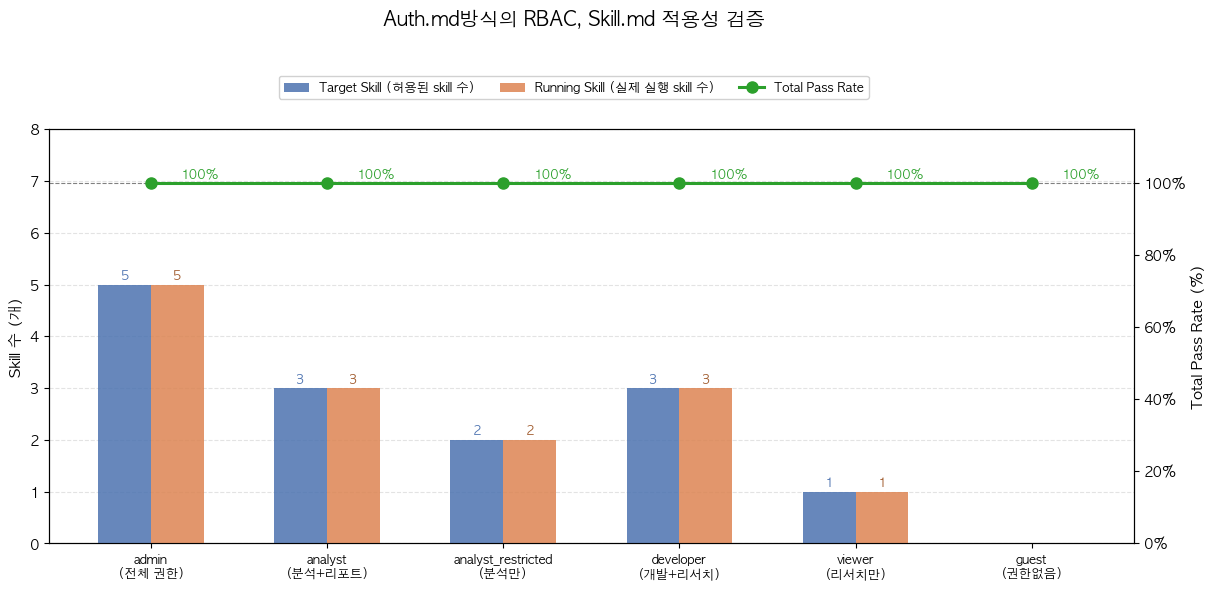

저장 완료: pass_rate_analysis.png


In [138]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

roles = ROLES_TO_TEST

target_counts  = [sum(1 for r in dynamic_results[role].query_results if r["auth_pass"]) for role in roles]
running_counts = [sum(1 for r in dynamic_results[role].query_results if r["exec_pass"]) for role in roles]
total_rates    = [dynamic_results[r].total_pass_rate * 100 for r in roles]

role_labels = [
    "admin\n(전체 권한)",
    "analyst\n(분석+리포트)",
    "analyst_restricted\n(분석만)",
    "developer\n(개발+리서치)",
    "viewer\n(리서치만)",
    "guest\n(권한없음)",
]

x = np.arange(len(roles))
w = 0.3

fig, ax1 = plt.subplots(figsize=(14, 6))

# ── 왼쪽 y축: skill 개수 (정수) ──
b1 = ax1.bar(x - w/2, target_counts,  width=w,
             label="Target Skill (허용된 skill 수)",     color="#4C72B0", alpha=0.85, zorder=3)
b2 = ax1.bar(x + w/2, running_counts, width=w,
             label="Running Skill (실제 실행 skill 수)", color="#DD8452", alpha=0.85, zorder=3)

ax1.set_ylabel("Skill 수 (개)", fontsize=11)
ax1.set_ylim(0, 8)
ax1.yaxis.set_major_locator(mticker.MultipleLocator(1))
ax1.set_xticks(x)
ax1.set_xticklabels(role_labels, fontsize=9, ha="center")
ax1.grid(axis="y", linestyle="--", alpha=0.35, zorder=0)

for bar in b1:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, h + 0.1, str(int(h)),
                 ha="center", fontsize=9, color="#4C72B0", fontweight="bold")
for bar in b2:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, h + 0.1, str(int(h)),
                 ha="center", fontsize=9, color="#a05a2c", fontweight="bold")

# ── 오른쪽 y축: Total Pass Rate (%) ──
ax2 = ax1.twinx()
ax2.plot(x, total_rates, color="#2ca02c", marker="o", linewidth=2.2,
         markersize=8, label="Total Pass Rate", zorder=5)
ax2.axhline(100, color="gray", linestyle="--", linewidth=0.8, zorder=1)
ax2.set_ylabel("Total Pass Rate (%)", fontsize=11)
ax2.set_ylim(0, 115)
ax2.set_yticks([0, 20, 40, 60, 80, 100])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}%"))

for xi, val in zip(x, total_rates):
    ax2.text(xi + 0.17, val + 1.5, f"{val:.0f}%",
             ha="left", fontsize=9, color="#2ca02c", fontweight="bold")

# ── figure 레벨 title (ax와 독립) ──
fig.suptitle("Auth.md방식의 RBAC, Skill.md 적용성 검증",
             fontsize=14, fontweight="bold", y=1.0)

# ── 범례: title 바로 아래 중앙 ──
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
fig.legend(lines1 + lines2, labels1 + labels2,
           loc="upper center", bbox_to_anchor=(0.5, 0.9),
           ncol=3, fontsize=9, framealpha=0.9, edgecolor="#cccccc")

plt.subplots_adjust(top=0.80)
plt.savefig("pass_rate_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("저장 완료: pass_rate_analysis.png")


---
## 결론

### 최종 구조

```
auth.md          → skill:* 스코프 + roles 정의
AuthContext      → can_access_skill() 단일 메서드
SKILL_REGISTRY   → skill:* 스코프 → StructuredTool 직접 매핑
create_agent()   → can_access_skill()로 필터링 → agent 생성
```

### 구조 진화

| 버전 | 구성 | 체크 |
|---|---|---|
| 원본 | auth.md(skill+tool) + skills.md(required_scope+tool_scopes) | 2회 |
| 중간 | auth.md(tool만) + skills.md(tool_scopes) | 1회 |
| 최종 | **auth.md(skill만) + SKILL_REGISTRY** | **1회, 단순** |

---

### 평가 방식

| 단계 | 이름 | 측정 방법 | 비용 |
|---|---|---|---|
| 1 | **Static** | auth.md 스코프 집합 연산으로 허용 skill 수 계산 | 무료, CI 편입 가능 |
| 2 | **Exec** | 명시적 지시문으로 agent 실행 → tool 실제 호출 여부 | LLM 호출 비용 발생 |
| 통합 | **Total** | 전체 30개 시나리오 정합률 (허용→호출 + 차단→미호출) | - |

**Static** = 이론값. LLM 없이 auth.md 만으로 계산.  
**Exec** = 실행 충실도. 허용된 skill 중 LLM이 실제 호출한 비율.  
**Total** = 시스템 전체 신뢰도. 차단도 정답이므로 포함.

**평가 흐름:**
```
auth.md roles → AuthContext.scopes
    ↓ can_access_skill() 필터
agent tool 목록 결정 (Static 확정)
    ↓ 명시적 쿼리로 agent.invoke()
wrap_for_tracking → tool 호출 여부 기록
    ↓
Exec Pass Rate / Total Pass Rate 계산
```

---

### 예시

**analyst_restricted (skill:research, skill:data_analysis 보유):**

| 쿼리 (명시적) | required_skill | tool 목록 | 실행 결과 |
|---|---|---|---|
| "research_skill을 호출해서..." | skill:research | ✓ 포함 | ✓ 호출됨 |
| "data_analysis_skill을 호출해서..." | skill:data_analysis | ✓ 포함 | ✓ 호출됨 |
| "reporting_skill을 호출해서..." | skill:reporting | ✗ 미포함 | - 차단(정상) |
| "notification_skill을 호출해서..." | skill:notification | ✗ 미포함 | - 차단(정상) |
| "code_review_skill을 호출해서..." | skill:code_review | ✗ 미포함 | - 차단(정상) |

→ Static 40% (2/5) | Exec 100% (2/2) | Total 100% (5/5)

**OTP 업그레이드 예시 (analyst_restricted → skill:reporting 획득):**
```python
diana_r.upgrade_scope("skill:reporting", reason="OTP claim confirmed")
# upgrade 후 반드시 create_agent(diana_r) 재호출 → 새 tool 목록 반영
```

---

### 현실적으로 체크해야 할 포인트

**1. scope 이름 case-sensitive 매칭**
- `skill:Research` ≠ `skill:research` → 타이포 하나로 해당 역할 전체 차단
- SKILL_REGISTRY 키와 auth.md scopes 섹션의 이름이 **정확히 일치**해야 함
- 권장: enum 또는 상수로 scope 이름 관리

**2. SKILL_REGISTRY ↔ auth.md 동기화 필수**
- auth.md에 scope 추가 → SKILL_REGISTRY에도 추가해야 tool 노출
- SKILL_REGISTRY에 tool 추가 → auth.md scopes에도 정의해야 upgrade 가능
- 둘 중 하나만 수정 시 영구 차단 또는 `upgrade_scope()` 무효

**3. scope 업그레이드 후 agent 재생성**
- `upgrade_scope()` 호출 후 기존 agent 인스턴스는 **이전 tool 목록 유지**
- 권한 변경이 발생하면 반드시 `create_agent(auth_ctx)` 재호출로 agent 교체

**4. guest / 빈 스코프 역할 처리**
- `create_agent()` 가 `None` 반환 → upstream에서 None 체크 없으면 AttributeError
- guest 역할은 에이전트 생성 전에 조기 차단(early return) 처리 권장

**5. Exec < Static 불일치의 의미**
- LLM이 허용된 tool을 호출하지 않는 것은 **auth 실패가 아님**
- 원인: tool description 불명확, 쿼리와 tool 의미 불일치
- 명시적 지시문(`tool_name을 호출해서`)으로 Exec ≈ Static 수렴 유도
- Exec < Static이 지속되면 tool description 개선 또는 프롬프트 재설계 필요

**6. Static 은 CI에 편입 가능, Exec는 정기 검증으로**
- Static: 결정론적 → 매 커밋 자동 검증, LLM 비용 없음
- Exec: LLM 실행 필요 → 배포 전 또는 모델 교체 시 정기 실행
  ```python
  EXPECTED_STATIC = {"admin": 1.0, "analyst": 0.6, "analyst_restricted": 0.4, ...}
  assert dynamic_results[role].static_pass_rate == EXPECTED_STATIC[role]
  ```

**7. auth.md YAML 파싱 실패 시 전체 시스템 무력화**
- frontmatter 형식 오류 → `ValueError` → `AuthContext` 생성 불가
- 운영 환경에서는 파싱 성공 여부를 startup health check에 포함 권장
